In [1]:
from importlib import reload
import torch
import numpy as np
import time
import os
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): # x is the data array; a and b are center coordinates
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:2


In [2]:
import pickle

with open("./Noise/noise=5%/cells_store.pkl", "rb") as f:
    cells_store=pickle.load(f)
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
S_num_proce=np.load("./Noise/noise=5%/S_num_1600+2400*2_0.0001.npy")
# Create data
S_num_store=np.load("./Noise/noise=5%/S_num_store.npy")

In [3]:
g_S=np.load("./Noise/noise=5%/g_S.npy")
g_S1=np.load("./Noise/noise=5%/g_S1.npy")

Number of detected clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.94
  Res_Rect=0.047597 vs Res_Ellip=0.142630
  center=(0.3854, 0.5068)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.243
Cluster 1: AR=1.02
  Res_Rect=0.094995 vs Res_Ellip=0.026702
  center=(0.7148, 0.4972)
  -> Decision: Circle (Sigmoid)


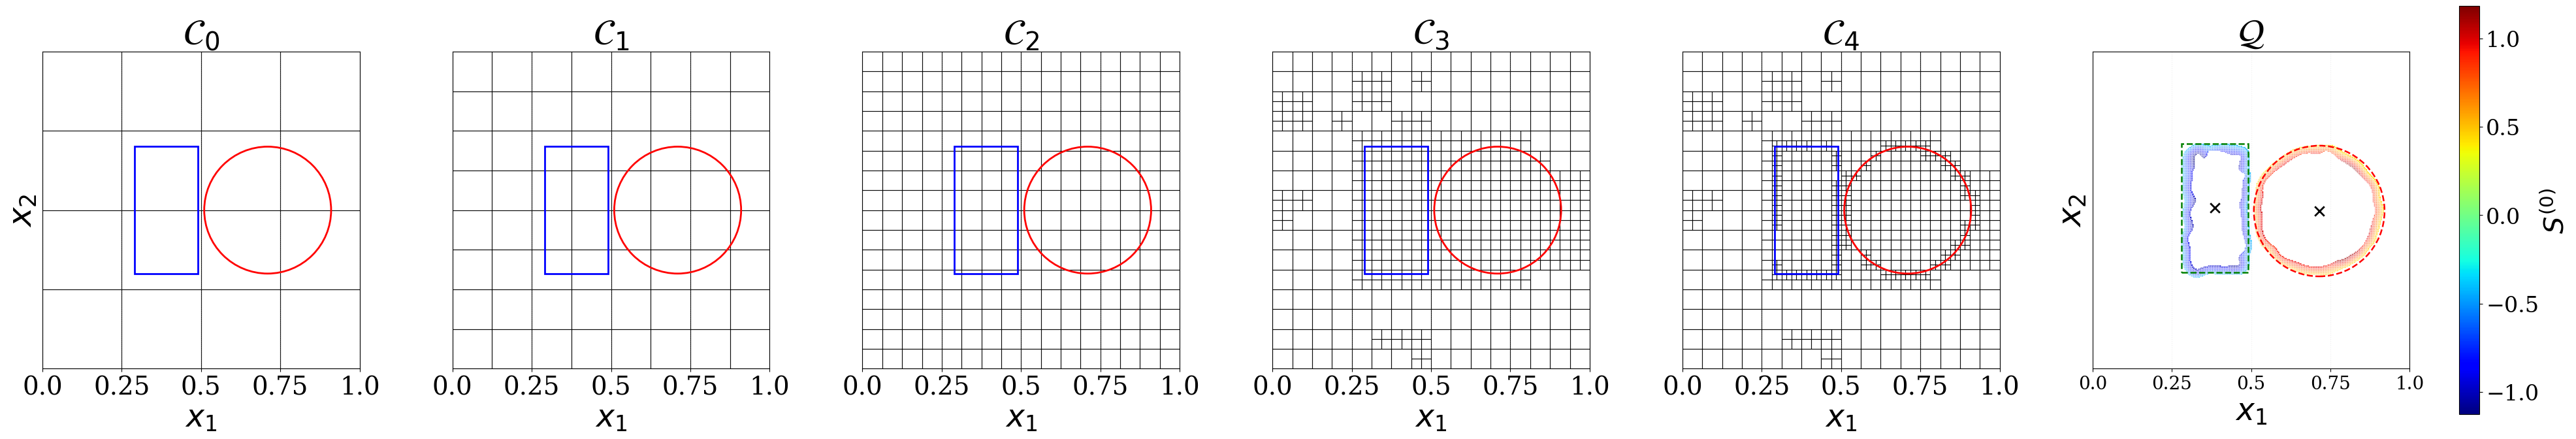

In [6]:
import bound_detect
reload(bound_detect)
import visual
reload(visual)
v=visual.GridMeshVisualizer()
fig=v.plot_mesh_evolution(cells_store, S_num_stores=S_num_store[-1], points=samples, save_path=None,label=True,g_S=g_S,temp=True)

In [7]:
fig.savefig("./Noise/noise=5%/mesh_evo_detect1.pdf", dpi=300, bbox_inches='tight')

Number of detected clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.94
  Res_Rect=0.047597 vs Res_Ellip=0.142630
  center=(0.3854, 0.5068)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.243
Cluster 1: AR=1.02
  Res_Rect=0.094995 vs Res_Ellip=0.026702
  center=(0.7148, 0.4972)
  -> Decision: Circle (Sigmoid)


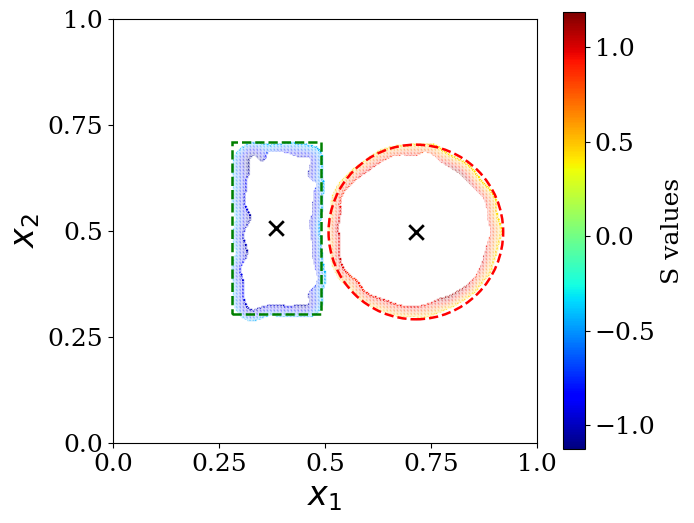

In [8]:
import bound_detect
reload(bound_detect)
tau_x_min=0.0
tau_x_max=1.0
tau_y_min=0.0
tau_y_max=1.0
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=5%", output_filename="detect.pdf", eps_mode="grid_scaled")

In [9]:
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
S_true=ana_S(samples,x_left,x_right,y_below,y_upper,center_true,r_true).reshape(len(x),len(y))

Plot saved as ./Noise/noise=5%/S_num.pdf


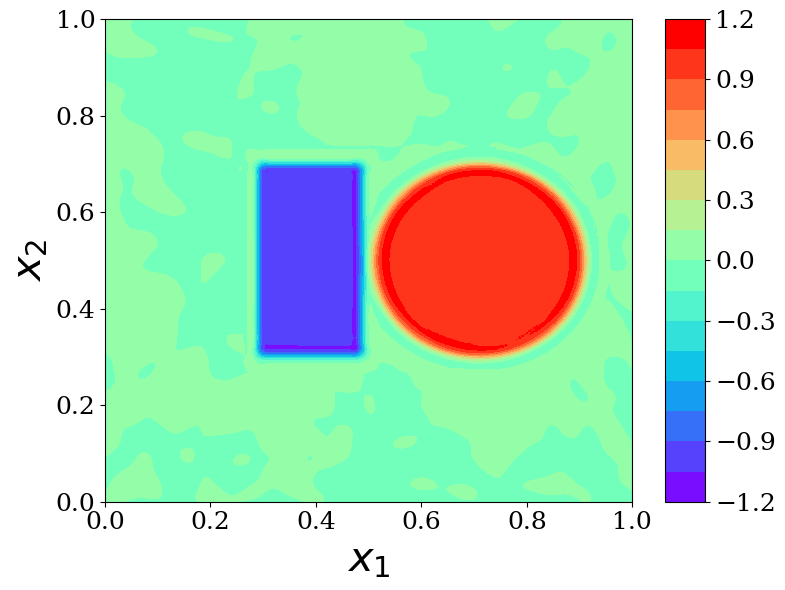

Plot saved as ./Noise/noise=5%/S_exact.pdf


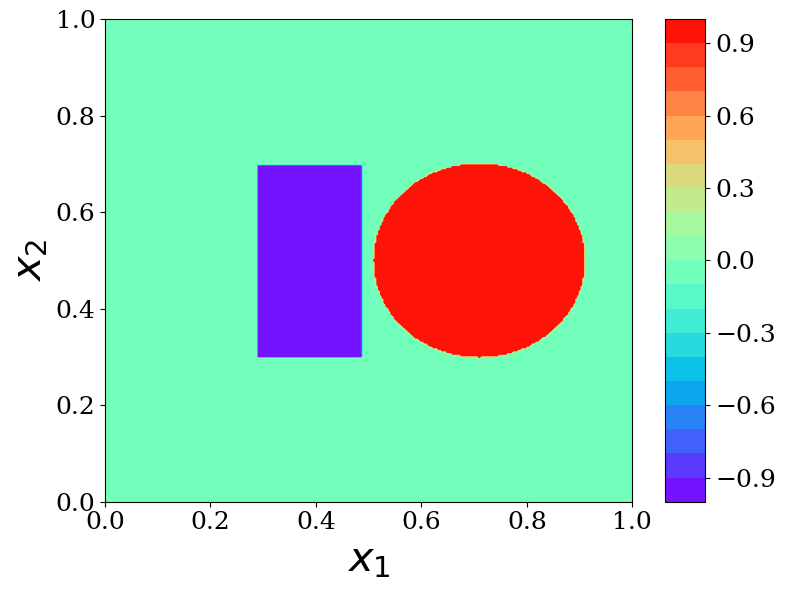

Plot saved as ./Noise/noise=5%/abs_S.pdf


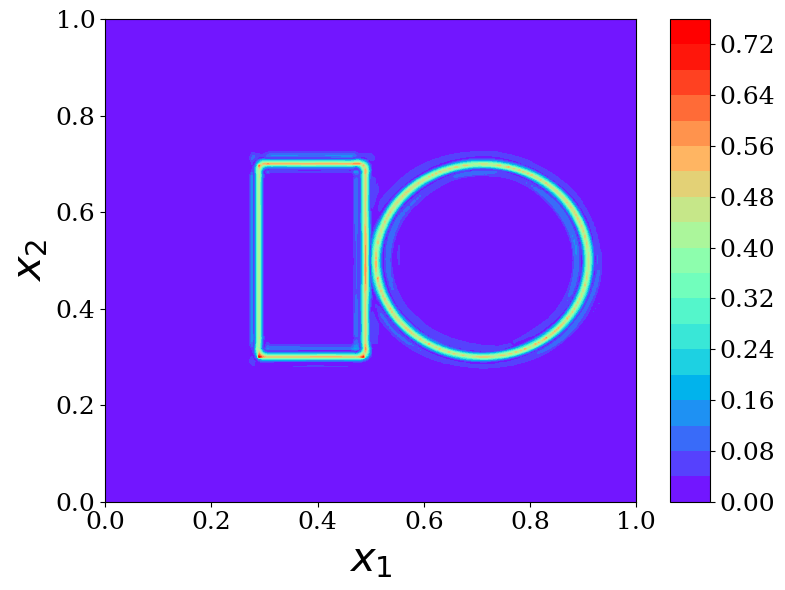

In [10]:
import visual
S_num=np.load("./Noise/noise=5%/S_num_1600+2400*2_0.0001.npy")
output_dictionary="./Noise/noise=5%/"
# visual.draw(X,Y,S_true,output_dictionary,"S_true")
visual.draw(X,Y,S_num,output_dictionary,"S_num.pdf")
visual.draw(X,Y,S_true,output_dictionary,"S_exact.pdf")
visual.draw(X,Y,np.abs(S_true-S_num),output_dictionary,"abs_S.pdf")